In [ ]:
#Carga de datos
import pandas as pd
import json
from Server_PD import download_dataframe_minio

#Graficas
import seaborn as sns        
import matplotlib.pyplot as plt
import isodate 

ModuleNotFoundError: No module named 'Server_PD'

In [1]:

with open("Private/Claves.json", "r", encoding="utf-8") as archivo:
    claves = json.load(archivo)
    
claves["Url"] = claves["Url"].replace("https://", "").replace("http://", "").split("/")[0]

df = download_dataframe_minio(
    bucket="pd1", 
    object_name="grupo1/df_videos_2026-02-25_09-54-10", 
    claves=claves, 
    file_format="parquet"
)

FileNotFoundError: [Errno 2] No such file or directory: 'Private/Claves.json'

In [ ]:

def iso_a_minutos(iso_duration):
    """"
    Funcion que convierte la duracion a minutos
    """
    try:
        duracion = isodate.parse_duration(iso_duration)
        return duracion.total_seconds() / 60
    except:
        return 0

df['Duracion'] = df['Duracion'].apply(iso_a_minutos)

In [ ]:
df_0_4 = df[df["Rango_edad"] == "0-4"]
df_5_8 = df[df["Rango_edad"] == "5-8"]
df_9_12 = df[df["Rango_edad"] == "9-12"]
df_Adult = df[df["Rango_edad"] == "Adult"].head(len(df_5_8))

In [ ]:
def graficar_histograma_duracion(df, titulo, ax_obj, color):
    """
    Función para graficar la distribución de duración.
    """
    # Histograma con curva de densidad
    sns.histplot(df['Duracion'], bins=30, kde=True, color=color, ax=ax_obj)
    
    ax_obj.set_title(titulo)
    ax_obj.set_xlabel('Minutos')
    ax_obj.set_ylabel('Cantidad de Vídeos')
    
    # Ajustamos el eje X (usamos el percentil 95 para ignorar vídeos extremadamente largos)
    limite_x = df['Duracion'].quantile(0.95)
    ax_obj.set_xlim(0, limite_x)

# Configuración
fig, ax = plt.subplots(2, 2, figsize=(12, 12), sharex=True, sharey=True)

# Llamamos a la función para cada grupo
graficar_histograma_duracion(df_Adult, 'Distribución Duración (Adultos)', ax[0, 0], 'darkkhaki')
graficar_histograma_duracion(df_0_4, 'Distribución Duración (0-4)', ax[0, 1], 'brown')
graficar_histograma_duracion(df_5_8, 'Distribución Duración (5-8)', ax[1, 0], 'khaki')
graficar_histograma_duracion(df_9_12, 'Distribución Duración (9-12)', ax[1, 1], 'powderblue')

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(5, 6))
sns.boxplot(x='Grupo', y='Duracion', data=df_total, palette='Set2')

# Ignoramos los outliers extremos solo en la vista, sin borrarlos del dataframe
limite_superior = df_total['Duracion'].quantile(0.95) * 1.2
plt.ylim(-5, limite_superior) 

plt.title('Comparativa de Duraciones')
plt.ylabel('Minutos')
plt.show()

In [ ]:

def graficar_top_generos(df, titulo_grafica, ax_obj, paleta):
    #  Limpiamos los datos
    generos = df['Generos'].astype(str).str.split(', ').explode()
    generos = generos[generos != 'nan']
    
    # top 10
    top_generos = generos.value_counts().head(10)
    
    # Grafica
    if not top_generos.empty:
        sns.barplot(x=top_generos.values, y=top_generos.index, palette=paleta, ax=ax_obj)
        ax_obj.set_title(titulo_grafica)
        ax_obj.set_xlabel('Frecuencia')
        ax_obj.set_ylabel('Género')
    else:
        ax_obj.set_title(f"{titulo_grafica} (Sin Datos)")

# Configuración
fig, ax = plt.subplots(4, 1, figsize=(10, 15), sharex=True)

# Llamamos a la función para cada grupo
graficar_top_generos(df_Adult, 'Top 10 Géneros Predominantes - Adultos', ax[0], 'viridis')
graficar_top_generos(df_0_4, 'Top 10 Géneros Predominantes - Rango (0-4)', ax[1], 'magma')
graficar_top_generos(df_5_8, 'Top 10 Géneros Predominantes - Rango (5-8)', ax[2], 'plasma')
graficar_top_generos(df_9_12, 'Top 10 Géneros Predominantes - Rango (9-12)', ax[3], 'inferno')

plt.tight_layout()
plt.show()

In [ ]:


def calcular_wpm(row):

    """"
    Función que devuelve el numero de palabras por minuto de un vídeo. (Numero total de palabras /
    duración total del vídeo)
    """
    
    # Convertimos a string y  limpiamos nulos  NO SE SI ES NECESARIO
    sub_texto = str(row['Subtitulos'])
    if sub_texto == "None" or sub_texto == "nan" or row['Duracion'] == 0:
        return 0
    
    numero_palabras = len(sub_texto.split())
    return numero_palabras / row['Duracion']




In [ ]:
#Agregamos una nueva columna a todos los df
df_Adult['Palabras_Por_Minuto'] = df_Adult.apply(calcular_wpm, axis=1)
df_Adult['Palabras_Por_Minuto'] = round(df_Adult['Palabras_Por_Minuto'], 2)

df_0_4['Palabras_Por_Minuto'] = df_0_4.apply(calcular_wpm, axis=1)
df_0_4['Palabras_Por_Minuto'] = round(df_0_4['Palabras_Por_Minuto'], 2)

df_5_8['Palabras_Por_Minuto'] = df_5_8.apply(calcular_wpm, axis=1)
df_5_8['Palabras_Por_Minuto'] = round(df_5_8['Palabras_Por_Minuto'], 2)

df_9_12['Palabras_Por_Minuto'] = df_9_12.apply(calcular_wpm, axis=1)
df_9_12['Palabras_Por_Minuto'] = round(df_9_12['Palabras_Por_Minuto'], 2)

In [ ]:
df_wpm_total = pd.concat([
    df_Adult.assign(Grupo='Adulto'),
    df_0_4.assign(Grupo='Niños 0-4'),
    df_5_8.assign(Grupo='Niños 5-8'),
    df_9_12.assign(Grupo='Niños 9-12')
])

# 2. Creamos el Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='Grupo', y='Palabras_Por_Minuto', data=df_wpm_total, palette='Set2')

plt.title('Comparativa de la Tasa de Habla por Grupo')
plt.xlabel('Grupo de Edad')
plt.ylabel('Palabras por Minuto')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from collections import Counter
import re

In [ ]:

# Lista extendida de stopwords en inglés
stopwords_en = {
    'the', 'and', 'a', 'to', 'of', 'in', 'is', 'it', 'you', 'that', 'he', 'was', 'for', 'on', 'are', 
    'with', 'as', 'I', 'his', 'they', 'be', 'at', 'one', 'have', 'this', 'from', 'or', 'had', 'by', 
    'hot', 'word', 'but', 'what', 'some', 'we', 'can', 'out', 'other', 'were', 'all', 'there', 
    'when', 'up', 'use', 'your', 'how', 'said', 'an', 'each', 'she', 'which', 'do', 'how', 'their', 
    'if', 'will', 'up', 'other', 'about', 'out', 'many', 'then', 'them', 'these', 'so', 'some', 
    'her', 'would', 'make', 'like', 'him', 'into', 'time', 'has', 'look', 'two', 'more', 'write', 
    'go', 'see', 'number', 'no', 'way', 'could', 'people', 'my', 'than', 'first', 'water', 'been', 
    'called', 'who', 'am', 'its', 'now', 'find', 'get', 'none'
}

""""
Funcion que devuelve el top n de palabras más comunes de un columna (título o subtitulos)
"""

def obtener_keywords_en(columna, top_n=20):
    todas_las_palabras = []
    
    for texto in columna:
        texto_limpio = str(texto).lower()
        # Solo extraemos letras
        palabras = re.findall(r'[a-z]+', texto_limpio)
        
        # Filtrar por longitud y stopwords
        palabras_filtradas = [p for p in palabras if p not in stopwords_en and len(p) > 3]
        todas_las_palabras.extend(palabras_filtradas)
    
    return Counter(todas_las_palabras).most_common(top_n)



In [ ]:

def graficar_palabras_comunes(df, columna, titulo_grafica, ax_obj, color):
    
    """"
    Funcion que genera un barplot de las top 10 palabras más comunes del título por cada grupo. 
    """

    keywords = obtener_keywords_en(df[columna], top_n=10)
    
    if not keywords:
        ax_obj.set_title(f"{titulo_grafica} (Sin datos)")
        return 

    # Desempaquetamos los resultados
    palabras_lista, conteos = zip(*keywords)
    
    # Dibujar grafica
    sns.barplot(x=list(conteos), y=list(palabras_lista), ax=ax_obj, color=color)
    ax_obj.set_title(titulo_grafica)
    ax_obj.set_xlabel('Frecuencia')
    ax_obj.set_ylabel('Palabra')


fig, ax = plt.subplots(2, 2, figsize=(15, 12))

graficar_palabras_comunes(df_Adult, 'Titulo', 'Top Keywords: Adultos', ax[0, 0], 'darkkhaki')
graficar_palabras_comunes(df_0_4, 'Titulo', 'Top Keywords: Niños 0-4', ax[0, 1], 'skyblue')
graficar_palabras_comunes(df_5_8, 'Titulo', 'Top Keywords: Niños 5-8', ax[1, 0], 'tomato')
graficar_palabras_comunes(df_9_12, 'Titulo', 'Top Keywords: Niños 9-12', ax[1, 1], 'darkmagenta')

plt.tight_layout()
plt.show()

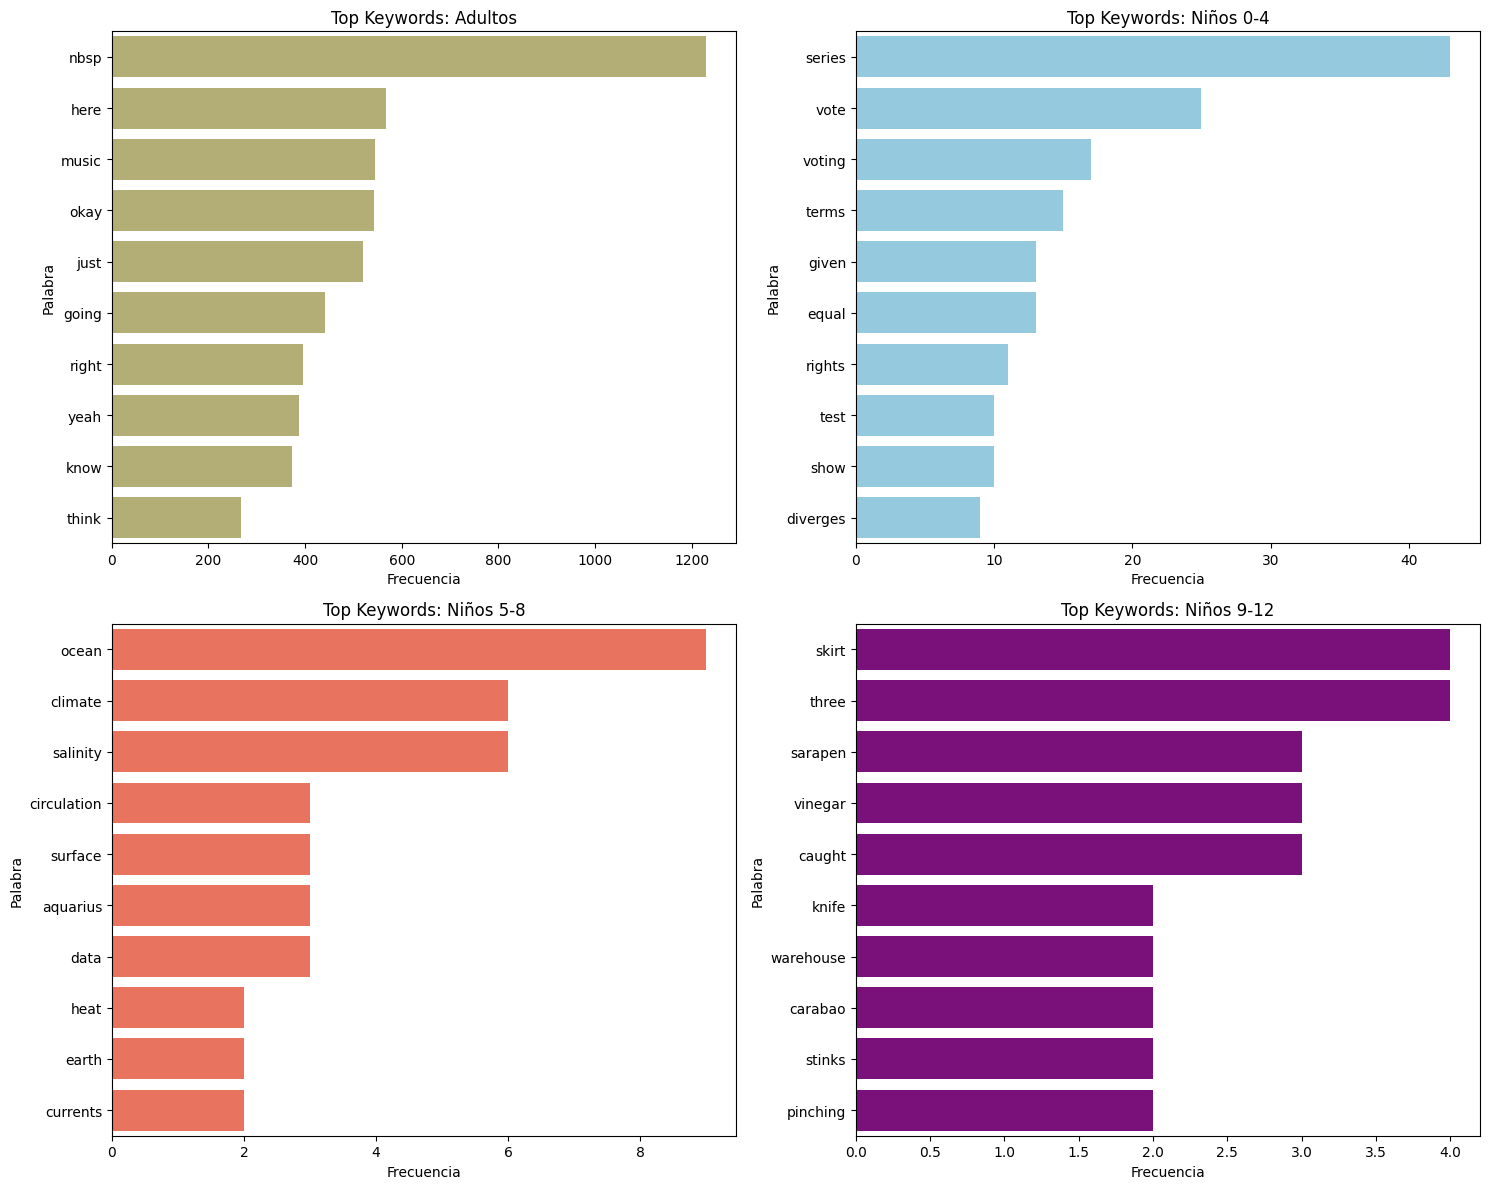

In [ ]:
#Con subtitulos en lugar de titulo
fig, ax = plt.subplots(2, 2, figsize=(15, 12))

graficar_palabras_comunes(df_Adult, 'Subtitulos', 'Top Keywords: Adultos', ax[0, 0], 'darkkhaki')
graficar_palabras_comunes(df_0_4, 'Subtitulos', 'Top Keywords: Niños 0-4', ax[0, 1], 'skyblue')
graficar_palabras_comunes(df_5_8, 'Subtitulos', 'Top Keywords: Niños 5-8', ax[1, 0], 'tomato')
graficar_palabras_comunes(df_9_12, 'Subtitulos', 'Top Keywords: Niños 9-12', ax[1, 1], 'darkmagenta')

plt.tight_layout()
plt.show()